# Week 6 Hand-in: Open Economy, Exchange Rates and the Peg

**Macroeconomics B -- Lectures 9 and 10**

This notebook is the starting point for the programming part of the hand-in. Write short Markdown answers after the code cells. Keep the answers concise and refer to your own numbers.

The notebook is self-contained. The small inflation panel below is a stylised Denmark/euro-area example used to practise the mechanism under a fixed nominal exchange rate.

## 1. Setup

We use the lecture notation:

$ i_t = i_t^f + \Delta e^e_{t+1}$,  
$ \Delta e^r_t = \Delta e_t + \pi^f_t - \pi_t$,  
$ \widehat y_t = \beta_1(q_{t-1}-\widehat\pi_t)+z_t$,  
$ \widehat\pi_t = \gamma \widehat y_t+s_t$,  
$ q_t = q_{t-1}-\widehat\pi_t$ under a fixed nominal exchange rate.

Here $q_t$ is the real-exchange-rate gap and $\widehat\pi_t=\pi_t-\pi^f$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

par = {
    'i_f': 0.025,   # foreign nominal interest rate, decimal
    'beta1': 0.70,  # trade/competitiveness channel in the fixed-peg AD curve
    'gamma': 0.50,  # AS slope
    'a_closed': 1.20,
    'beta2': 0.40,  # used ONLY in Part 1 Q4 (analytical); in Part 3-5 simulations beta2 is absorbed into z_t (cf. Lecture 10 Appendix A)
}

**Task 1.1: Log-linear UIP derivation**

Exact UIP is defined by: 

$$
1+i_t = (1+i^f_t) E^e_{t+1}/E_t
$$ 

Taking logs yields: 

$$
\ln(1+i_t) = \ln(1+i^f_t) + \ln E^e_{t+1} - \ln E_t
$$

Using the approximation $\ln(1+x) \approx x$ for small $x$, we obtain:
$$
i_t \approx i^f_t + \Delta e^e_{t+1}
$$

## 2. UIP, credibility and expected devaluation

Complete the functions and produce a table for the four scenarios from Part 1 of the hand-in.

Use decimals in the code. For example, 2.5 percent is `0.025`.

In [2]:
def uip_rate_log(i_f, expected_depreciation):
    return i_f + expected_depreciation

def uip_rate_exact(i_f, expected_log_depreciation):
    return (1 + i_f) * np.exp(expected_log_depreciation) - 1

scenarios = pd.DataFrame({
    'scenario': ['credible peg', 'mild pressure', 'severe pressure', 'expected appreciation'],
    'expected_depreciation': [0.00, 0.20 * 0.06, 0.40 * 0.10, -0.01],
})

scenarios['i_exact'] = uip_rate_exact(par['i_f'], scenarios['expected_depreciation'])
scenarios['i_log'] = uip_rate_log(par['i_f'], scenarios['expected_depreciation'])
scenarios


,scenario,expected_depreciation,i_exact,i_log
0,credible peg,0.000,0.025000,0.025
1,mild pressure,0.012,0.037374,0.037
2,severe pressure,0.040,0.066831,0.065
3,expected appreciation,-0.010,0.014801,0.015


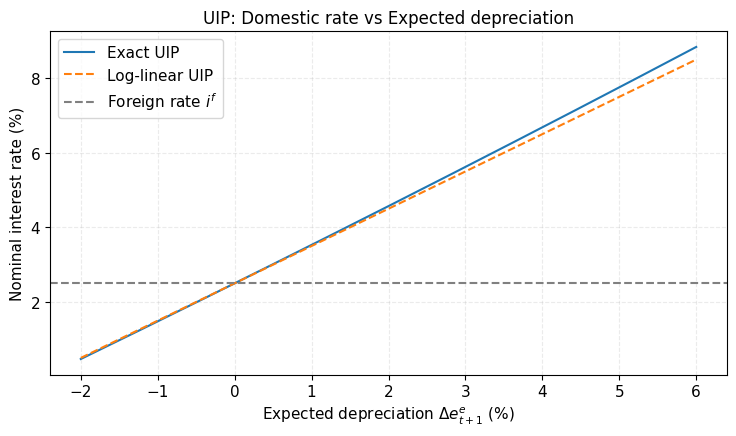

In [3]:
dep_grid = np.linspace(-0.02, 0.06, 200)
i_exact = uip_rate_exact(par['i_f'], dep_grid)
i_log = uip_rate_log(par['i_f'], dep_grid)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(100 * dep_grid, 100 * i_exact, label='Exact UIP')
ax.plot(100 * dep_grid, 100 * i_log, label='Log-linear UIP', linestyle='--')
ax.axhline(100 * par['i_f'], color='grey', ls='--', label='Foreign rate $i^f$')
ax.set_title('UIP: Domestic rate vs Expected depreciation')
ax.set_xlabel(r'Expected depreciation $\Delta e^e_{t+1}$ (%)')
ax.set_ylabel('Nominal interest rate (%)')
ax.legend()
fig.tight_layout()
plt.show()


**Interpretation.** 
If investors expect a currency to devalue, they will move their capital elsewhere to avoid losses. As a consequence, even a unrealised devaluation will lower the currency's exchange rate, due to the lower currency demand. To maintain a credible peg, the country must therefor increase domestic rate.  

## 3. Real exchange rate and Marshall-Lerner

A fixed nominal exchange rate means $\Delta e_t=0$, so the real exchange rate moves with the inflation differential.

#### Task 2.1 (yes, it is incredible confusing the structure of this, but i assume this is what is wanted wrt. the pdf)

$$E^r_t = \frac{E_t P^f_t}{P_t}$$

$$\ln(E^r_t) = \ln(E_t) + \ln(P^f_t) - \ln(P_t)$$

$$e^r_t = e_t + p^f_t - p_t$$

$$\Delta e^r_t = \Delta e_t + \Delta p^f_t - \Delta p_t$$

$$\Delta e^r_t = \Delta e_t + \pi^f_t - \pi_t$$

In [4]:
def real_exchange_rate_change(nominal_depreciation, pi_foreign, pi_domestic):
    return nominal_depreciation + pi_foreign - pi_domestic

def ml_trade_balance_effect(real_depreciation, eps_x, eps_m, quantity_adjustment=1.0):
    return (quantity_adjustment * (eps_x + eps_m) - 1) * real_depreciation



### 2.2

In [17]:
cases = [("Scenario A",0.012,0.030),("Scenario B", 0.035,0.02)]

data = []
for name, pi, pi_f in cases:
    # Calculate change
    delta_er = real_exchange_rate_change(0, pi_f, pi)
    
    # Determine competitiveness direction
    competitiveness = "Improves" if delta_er > 0 else "Worsens"
    
    data.append({
        "Scenario": name,
        "Domestic Inflation": pi,
        "Foreign Inflation": pi_f,
        "Change in Real ER": delta_er,
        "Competitiveness": competitiveness
    })

result = pd.DataFrame(data)
result

,Scenario,Domestic Inflation,Foreign Inflation,Change in Real ER,Competitiveness
0,Scenario A,0.012,0.03,0.018,Improves
1,Scenario B,0.035,0.02,-0.015,Worsens


### 2.3 and onwards

In [6]:

ml_cases = pd.DataFrame({
    'eps_x': [0.4, 0.7, 1.2],
    'eps_m': [0.3, 0.5, 0.6],
})
ml_cases['delta_NX_pct'] = ml_trade_balance_effect(5.0, ml_cases['eps_x'], ml_cases['eps_m'])
ml_cases

,eps_x,eps_m,delta_NX_pct
0,0.4,0.3,-1.5
1,0.7,0.5,1.0
2,1.2,0.6,4.0


In [7]:
eps_x_lr = 0.7
eps_m_lr = 0.5
real_dep = 5.0

nx_q1 = ml_trade_balance_effect(real_dep, eps_x_lr, eps_m_lr, quantity_adjustment=0.2)
nx_lr = ml_trade_balance_effect(real_dep, eps_x_lr, eps_m_lr, quantity_adjustment=1.0)

print(f'Q1 trade balance effect: {nx_q1:.2f}%')
print(f'LR trade balance effect: {nx_lr:.2f}%')


Q1 trade balance effect: -3.80%
LR trade balance effect: 1.00%


**J-curve interpretation.** In the short run, trade quantities are fixed by contracts while import prices rise immediately due to the depreciation. This causes the trade balance to initially worsen (a negative effect) before quantities adjust in the long run to satisfy the Marshall-Lerner condition and improve the balance.


## 4. A stylised Denmark/euro-area inflation differential

The data below are embedded to keep the notebook portable. Treat them as a stylised monthly path for year-on-year inflation rates.

**Note on notation.** In this section we build a *real-exchange-rate level index* with Jan 2021 = 100. This is NOT the same object as the model gap $q_t$ used in Section 5 (which is a deviation from long-run equilibrium). The driving formula is the same identity $\Delta e^r_t = \pi^f_t-\pi_t$, just expressed in monthly index points:

$\text{rer\_index}_t = \text{rer\_index}_{t-1} + (\pi^f_t - \pi_t)/12.$

We divide by 12 because the inflation series is annual % year-on-year and we want a monthly increment.

In [8]:
def make_inflation_panel():
    dates = pd.date_range('2021-01-01', '2026-04-01', freq='MS')
    t = np.arange(len(dates))
    dk = np.interp(t, [0, 12, 24, 36, 48, 60, 63], [0.4, 1.8, 8.5, 3.3, 1.3, 1.6, 1.2])
    ea = np.interp(t, [0, 12, 24, 36, 48, 60, 63], [0.3, 2.6, 8.4, 5.4, 2.4, 2.2, 3.0])
    return pd.DataFrame({'Denmark': dk, 'Euro area': ea}, index=dates)

infl = make_inflation_panel()
infl.tail()

,Denmark,Euro area
2025-12-01,1.575000,2.216667
2026-01-01,1.600000,2.200000
2026-02-01,1.466667,2.466667
2026-03-01,1.333333,2.733333
2026-04-01,1.200000,3.000000


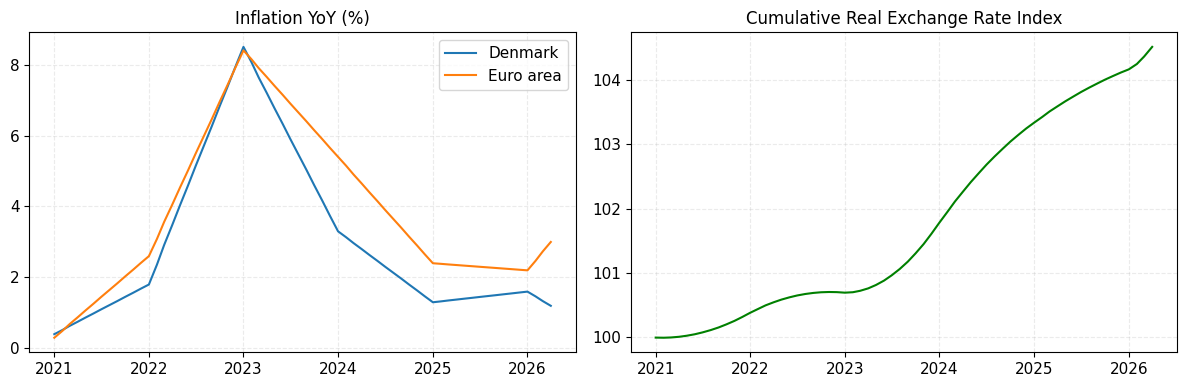

In [9]:
monthly_diff = (infl['Euro area'] - infl['Denmark']) / 12.0
infl['rer_index'] = 100.0 + monthly_diff.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(infl.index, infl['Denmark'], label='Denmark')
axes[0].plot(infl.index, infl['Euro area'], label='Euro area')
axes[0].set_title('Inflation YoY (%)')
axes[0].legend()

axes[1].plot(infl.index, infl['rer_index'], color='green')
axes[1].set_title('Cumulative Real Exchange Rate Index')
fig.tight_layout()
plt.show()


**Interpretation.** Danish price competitiveness deteriorates after 2023. During this period, Danish inflation exceeds euro-area inflation ($\pi > \pi^f$, so $\pi^f - \pi < 0$), causing a real appreciation and a decline in the real exchange rate index.


## Part 3: The Fixed-Rate AS-AD Model

#### Task 3.1: 
To solve for $\hat{y}_t$ and $\hat{\pi}_t$ as functions of $q_{t-1}$, $z_t$, and $s_t$, substitute the AS equation into the AD equation:

$$\hat{y}_t = \beta_1 \left( q_{t-1} - (\gamma \hat{y}_t + s_t) \right) + z_t$$

Expanding and isolating $\hat{y}_t$:

$$\hat{y}_t (1 + \beta_1 \gamma) = \beta_1 q_{t-1} + z_t - \beta_1 s_t$$

$$\hat{y}_t = \frac{\beta_1}{1 + \beta_1 \gamma} q_{t-1} + \frac{1}{1 + \beta_1 \gamma} z_t - \frac{\beta_1}{1 + \beta_1 \gamma} s_t$$

Substitute $\hat{y}_t$ back into the AS equation to find $\hat{\pi}_t$:

$$\hat{\pi}_t = \gamma \left( \frac{\beta_1}{1 + \beta_1 \gamma} q_{t-1} + \frac{1}{1 + \beta_1 \gamma} z_t - \frac{\beta_1}{1 + \beta_1 \gamma} s_t \right) + s_t$$

$$\hat{\pi}_t = \frac{\beta_1 \gamma}{1 + \beta_1 \gamma} q_{t-1} + \frac{\gamma}{1 + \beta_1 \gamma} z_t + \left( 1 - \frac{\beta_1 \gamma}{1 + \beta_1 \gamma} \right) s_t$$

$$\hat{\pi}_t = \frac{\beta_1 \gamma}{1 + \beta_1 \gamma} q_{t-1} + \frac{\gamma}{1 + \beta_1 \gamma} z_t + \frac{1}{1 + \beta_1 \gamma} s_t$$



#### Task 3.2

Setting $z_t = s_t = 0$, and substituting $\hat{\pi}_t$ into the RER law of motion ($q_t = q_{t-1} - \hat{\pi}_t$) yields:

$$q_t = q_{t-1} - \frac{\beta_1 \gamma}{1 + \beta_1 \gamma} q_{t-1} = \left( 1 - \frac{\beta_1 \gamma}{1 + \beta_1 \gamma} \right) q_{t-1}$$

$$q_t = \frac{1}{1 + \beta_1 \gamma} q_{t-1}$$

Since $\beta_1 > 0$ and $\gamma > 0$, the root satisfies $0 < \frac{1}{1 + \beta_1 \gamma} < 1$. This ensures monotonic convergence toward long-run equilibrium. Economically, an overvalued currency ($q < 0$) depresses demand ($\hat{y} < 0$), generating domestic deflation relative to abroad ($\hat{\pi} < 0$), which restores price competitiveness.

Utilizing the results from task 3.1 and the defintion of defintion of $q_t$ from above we can compute the AD, AS, and RER for period 1 given $q_0 = -2$, $z_1 = s_1 = 0$, $\beta_1 = 0.7$, and $\gamma = 0.5$. This yields:

$$\hat{y}_1 = \frac{\beta_1}{1 + \beta_1 \gamma} q_0 = \frac{0.7}{1 + (0.7 \times 0.5)} (-2) = \frac{0.7}{1.35} (-2) \approx -1.037$$

$$\hat{\pi}_1 = \frac{\beta_1 \gamma}{1 + \beta_1 \gamma} q_0 = \frac{0.7 \times 0.5}{1 + (0.7 \times 0.5)} (-2) = \frac{0.35}{1.35} (-2) \approx -0.519$$

$$q_1 = \frac{1}{1 + \beta_1 \gamma} q_0 = \frac{1}{1 + (0.7 \times 0.5)} (-2) = \frac{1}{1.35} (-2) \approx -1.481$$

#### Task 3.3
Given $z_1 = 1$, $q_0 = 0$:
$$\hat{y}_1 = \frac{1}{1.35} (1) \approx 0.741$$
$$\hat{\pi}_1 = \frac{0.5}{1.35} (1) \approx 0.370$$
$$q_1 = 0 - 0.370 = -0.370$$

At $t = 2$, the stimulus ends ($z_2 = 0$), leaving an overvalued currency ($q_1 = -0.370$):
$$\hat{y}_2 = \frac{0.7}{1.35} (-0.370) \approx -0.192$$

**Interpretation:** The temporary fiscal expansion drives up domestic inflation, leading to a real appreciation ($q_1 < 0$). Once the stimulus vanishes, this accumulated loss of price competitiveness depresses net exports, pulling output below potential (a "competitiveness hangover") until domestic deflation clears the imbalance.


#### Task 3.4: Temporary Adverse Supply Shock

Given $s_1 = 0.8$, $q_0 = 0$:
$$\hat{y}_1 = -\frac{0.7}{1.35} (0.8) \approx -0.415$$
$$\hat{\pi}_1 = \frac{1}{1.35} (0.8) \approx 0.593$$
$$q_1 = 0 - 0.593 = -0.593$$

**Explanation:** The cost-push shock directly boosts inflation ($\hat{\pi}_1 > 0$) and contracts aggregate demand ($\hat{y}_1 < 0$). Under the fixed peg, the spike in domestic inflation initiates a real currency overvaluation ($q_1 < 0$). When the supply shock fades, this lingering overvaluation will continue to depress output until competitiveness is regained.

## 5. Fixed-rate AS-AD simulation

Complete the simulation function. The timing is:

1. inherit $q_{t-1}$,
2. solve AD and AS for $\widehat y_t$ and $\widehat\pi_t$,
3. update $q_t=q_{t-1}-\widehat\pi_t$.

In [10]:
def simulate_peg(T, beta1, gamma, z_path=None, s_path=None, q0=0.0):
    if z_path is None:
        z_path = np.zeros(T)
    if s_path is None:
        s_path = np.zeros(T)
    z_path = np.asarray(z_path, dtype=float)
    s_path = np.asarray(s_path, dtype=float)

    yhat = np.empty(T)
    pihat = np.empty(T)
    q = np.empty(T)
    q_lag = q0

    for t in range(T):
        yhat[t] = (beta1 * q_lag + z_path[t] - beta1 * s_path[t]) / (1.0 + beta1 * gamma)
        pihat[t] = gamma * yhat[t] + s_path[t]
        q[t] = q_lag - pihat[t]
        q_lag = q[t]

    return pd.DataFrame({
        'period': np.arange(1, T + 1),
        'z': z_path,
        's': s_path,
        'yhat': yhat,
        'pihat': pihat,
        'q': q,
    })

T = 30
z_path = np.zeros(T)
z_path[0] = 1.0
peg = simulate_peg(T, par['beta1'], par['gamma'], z_path=z_path)
peg.head()


,period,z,s,yhat,pihat,q
0,1,1.0,0.0,0.740741,0.370370,-0.370370
1,2,0.0,0.0,-0.192044,-0.096022,-0.274348
2,3,0.0,0.0,-0.142255,-0.071127,-0.203221
3,4,0.0,0.0,-0.105374,-0.052687,-0.150534
4,5,0.0,0.0,-0.078055,-0.039027,-0.111507


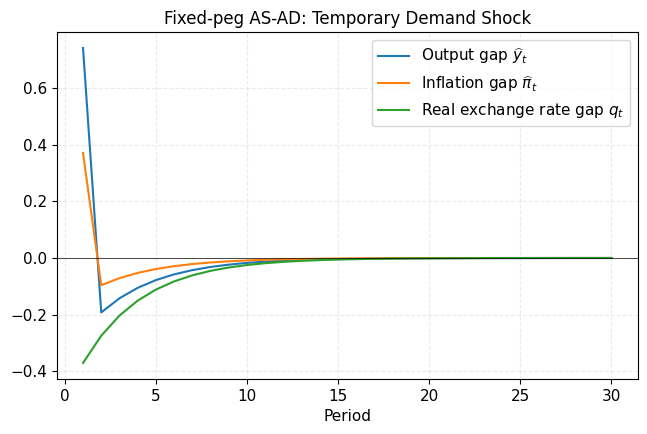

The competitiveness hangover begins in period 2.


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(peg['period'], peg['yhat'], label=r'Output gap $\widehat{y}_t$')
ax.plot(peg['period'], peg['pihat'], label=r'Inflation gap $\widehat{\pi}_t$')
ax.plot(peg['period'], peg['q'], label='Real exchange rate gap $q_t$')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Fixed-peg AS-AD: Temporary Demand Shock')
ax.set_xlabel('Period')
ax.legend()
plt.show()

hangover_period = peg.loc[(peg['period'] > 1) & (peg['yhat'] < 0), 'period'].iloc[0]
print(f'The competitiveness hangover begins in period {hangover_period}.')


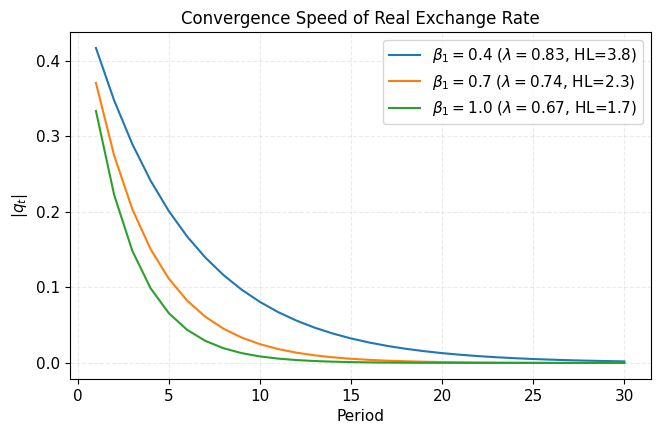

In [12]:
beta1_vals = [0.4, 0.7, 1.0]
fig, ax = plt.subplots(figsize=(7.5, 4.5))

for b1 in beta1_vals:
    sim = simulate_peg(T, b1, par['gamma'], z_path=z_path)
    root = 1 / (1 + b1 * par['gamma'])
    halflife = np.log(0.5) / np.log(root)
    ax.plot(sim['period'], np.abs(sim['q']), label=rf'$\beta_1={b1}$ ($\lambda={root:.2f}$, HL={halflife:.1f})')

ax.set_title('Convergence Speed of Real Exchange Rate')
ax.set_xlabel('Period')
ax.set_ylabel('$|q_t|$')
ax.legend()
plt.show()


## 6. Comparison with the closed-economy AS-AD model

In the closed-economy model with static expectations:

$ \widehat y_t = z_t - a\widehat\pi_t$,  
$ \widehat\pi_t = \widehat\pi_{t-1} + \gamma\widehat y_t$.

The same temporary demand expansion can create a later downturn, but the state variable is different.

**Note on $\widehat\pi_t$.** In the fixed-peg model of Sections 3 and 5, $\widehat\pi_t = \pi_t - \pi^f$ (deviation from foreign inflation, the peg's nominal anchor). In the closed-economy model here there is no foreign anchor, so $\widehat\pi_t$ is the deviation from the steady-state inflation target. Static expectations means $\pi^e_t = \pi_{t-1}$, which produces the lagged term in AS. The slope $a$ is the reduced-form sensitivity of demand to inflation (it bundles the real-rate channel and a Taylor-type monetary response).

In [13]:
def simulate_closed(T, a, gamma, z_path=None, s_path=None, pihat0=0.0):
    if z_path is None:
        z_path = np.zeros(T)
    if s_path is None:
        s_path = np.zeros(T)
    z_path = np.asarray(z_path, dtype=float)
    s_path = np.asarray(s_path, dtype=float)

    yhat = np.empty(T)
    pihat = np.empty(T)
    pi_lag = pihat0
    beta = 1 / (1 + a * gamma)

    for t in range(T):
        pihat[t] = beta * pi_lag + gamma * beta * z_path[t] + beta * s_path[t]
        yhat[t] = z_path[t] - a * pihat[t]
        pi_lag = pihat[t]

    return pd.DataFrame({'period': np.arange(1, T + 1), 'z': z_path, 's': s_path,
                         'yhat': yhat, 'pihat': pihat})

closed = simulate_closed(T, par['a_closed'], par['gamma'], z_path=z_path)
closed.head()


,period,z,s,yhat,pihat
0,1,1.0,0.0,0.625000,0.312500
1,2,0.0,0.0,-0.234375,0.195312
2,3,0.0,0.0,-0.146484,0.122070
3,4,0.0,0.0,-0.091553,0.076294
4,5,0.0,0.0,-0.057220,0.047684


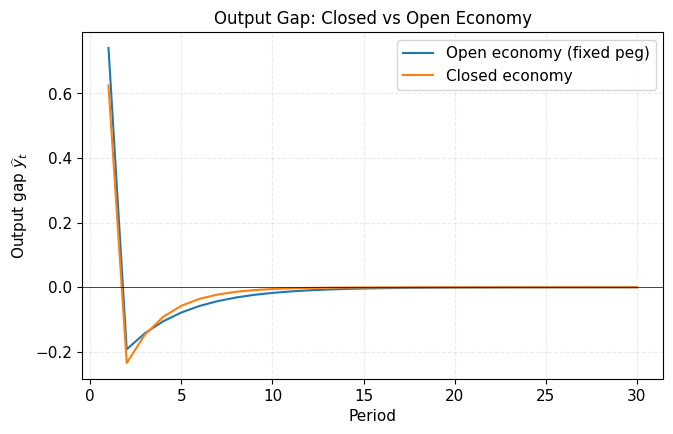

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(peg['period'], peg['yhat'], label='Open economy (fixed peg)')
ax.plot(closed['period'], closed['yhat'], label='Closed economy')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Output Gap: Closed vs Open Economy')
ax.set_xlabel('Period')
ax.set_ylabel(r'Output gap $\widehat{y}_t$')
ax.legend()
plt.show()


**Interpretation.** The closed economy adjusts much faster because the central bank actively stabilizes demand by raising interest rates (strong response parameter $a$). In the open economy with a peg, monetary policy is constrained, so adjustment relies on the slower real-exchange-rate channel (via accumulated inflation differentials changing competitiveness).


## 7. Short policy memo

Write 250--350 words. Use the numerical results above and answer the memo question from Part 5 of the hand-in.

#### Policy memo

Under the current circumstances, we have three possible outcomes which must be discussed.

The first and most risky option is the devaluation of the exchange rate by running an independent monetary policy. This will effectively end the fixed exchange rate policy by the principles of the trilemma. The independent monetary policy would allow us to lower rates and quickly overcome the recession. However, it is likely that Denmark would have a higher structural interest rate given the loss of reputation, leading to lower long term economic prosperity. This is especially problematic for Denmark, as we rely on the openness of our economy. It is also worth emphasizing that if markets begin to expect a devaluation (UIP) dictates that domestic interest rates must rise immediately to compensate investors for expected currency losses, thus resulting in the worst of both worlds.

The second option is fiscal expansion. This offers immediate relief but carries medium term costs. A stimulus will raise domestic demand and push our inflation rate above the euro area's. Over time, this inflation differential creates a real appreciation, making Danish goods relatively more expensive. When the fiscal stimulus eventually ends, the economy will suffer a "competitiveness hangover" output will fall below potential because of the accumulated real appreciation, leading to a slow recovery.

The third option is to wait. Under a credible peg, a recession naturally exerts downward pressure on domestic inflation. As our inflation falls below the euro area's, the Danish krone depreciates in real terms. This automatic improvement in price competitiveness will organically stimulate net exports and shift aggregate demand outward, leading to a sustainable, export-led recovery without undermining the credibility of the peg or inducing a future hangover. In short - The real exchange rate adjustment will lift us out of the recession, but more slowly than Option 1. The benefit, however, is that we remain credibly pegged.

My suggestion is to: 1) Reject the considerations of devaluation very clearly 2) Motivate the populace and government officials to wait; and 3) Minimize fiscal expansion for the benefit of long-term growth, while using it strategically to satisfy political demands.
